In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)


In [4]:
df = pd.read_csv(
    "../data/raw/insurance_data.csv",
    sep="|",          # <-- use pipe as separator, not comma
    engine="python"   # <-- more tolerant parser for weird lines
)

df.head()


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [5]:
# Convert TransactionMonth into a proper datetime format
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

# Columns that should be treated as categories (not numbers)
categorical_cols = [
    "Province", 
    "PostalCode", 
    "Gender", 
    "VehicleType", 
    "Make", 
    "Model"
]

# Convert each categorical column into category data type
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

df.head()


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [6]:
# Avoid dividing by zero (some premiums may be 0)
df['LossRatio'] = np.where(
    df['TotalPremium'] > 0,
    df['TotalClaims'] / df['TotalPremium'],
    np.nan
)

# Margin = profit = Premium - Claims
df['Margin'] = df['TotalPremium'] - df['TotalClaims']

# Whether the policy had at least one claim (1 = Yes, 0 = No)
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

df[['TotalPremium', 'TotalClaims', 'LossRatio', 'Margin', 'HasClaim']].head()


,TotalPremium,TotalClaims,LossRatio,Margin,HasClaim
0,21.929825,0.0,0.0,21.929825,0
1,21.929825,0.0,0.0,21.929825,0
2,0.000000,0.0,NaN,0.000000,0
3,512.848070,0.0,0.0,512.848070,0
4,0.000000,0.0,NaN,0.000000,0


In [7]:
# Check missing values sorted from highest to lowest
missing = df.isna().sum().sort_values(ascending=False)

missing.head(30)   # show the top 30 columns with missing values


NumberOfVehiclesInFleet     1000098
CrossBorder                  999400
CustomValueEstimate          779642
WrittenOff                   641901
Converted                    641901
Rebuilt                      641901
LossRatio                    381922
NewVehicle                   153295
Bank                         145961
AccountType                   40232
Gender                         9536
MaritalStatus                  8259
make                            552
VehicleIntroDate                552
bodytype                        552
kilowatts                       552
cubiccapacity                   552
Cylinders                       552
Model                           552
NumberOfDoors                   552
mmcode                          552
VehicleType                     552
CapitalOutstanding                2
StatutoryClass                    0
Margin                            0
TotalClaims                       0
TotalPremium                      0
StatutoryRiskType           

In [8]:
total_claims = df['TotalClaims'].sum()
total_premium = df['TotalPremium'].sum()

overall_loss_ratio = total_claims / total_premium
overall_loss_ratio


np.float64(1.0477452570332206)

In [9]:
province_stats = df.groupby("Province").agg(
    total_claims=("TotalClaims", "sum"),
    total_premium=("TotalPremium", "sum")
)

province_stats["loss_ratio"] = province_stats["total_claims"] / province_stats["total_premium"]
province_stats = province_stats.sort_values("loss_ratio", ascending=False)

province_stats


/var/folders/dz/l6x16v5x1hd4d44d0yd1wfx00000gn/T/ipykernel_2154/21158659.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  province_stats = df.groupby("Province").agg(


,total_claims,total_premium,loss_ratio
Province,,,
Gauteng,2.939415e+07,2.405377e+07,1.222018
KwaZulu-Natal,1.430138e+07,1.320908e+07,1.082693
Western Cape,1.038977e+07,9.806559e+06,1.059472
North West,5.920250e+06,7.490508e+06,0.790367
Mpumalanga,2.044675e+06,2.836292e+06,0.720897
Free State,3.549223e+05,5.213632e+05,0.680758
Limpopo,1.016477e+06,1.537324e+06,0.661199
Eastern Cape,1.356427e+06,2.140104e+06,0.633813
Northern Cape,8.949051e+04,3.165581e+05,0.282699


/var/folders/dz/l6x16v5x1hd4d44d0yd1wfx00000gn/T/ipykernel_2154/1874076252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


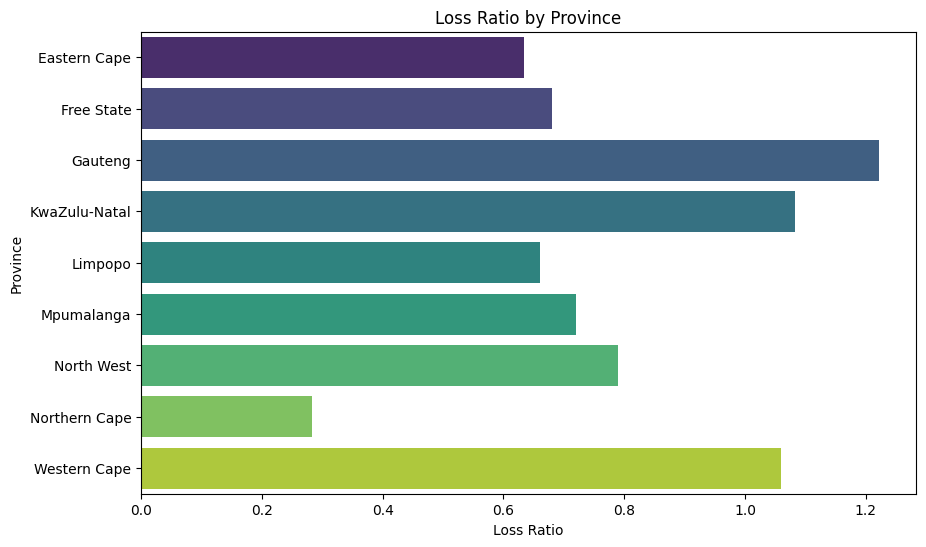

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=province_stats.reset_index(),
    x="loss_ratio",
    y="Province",
    palette="viridis"
)
plt.title("Loss Ratio by Province")
plt.xlabel("Loss Ratio")
plt.ylabel("Province")
plt.show()


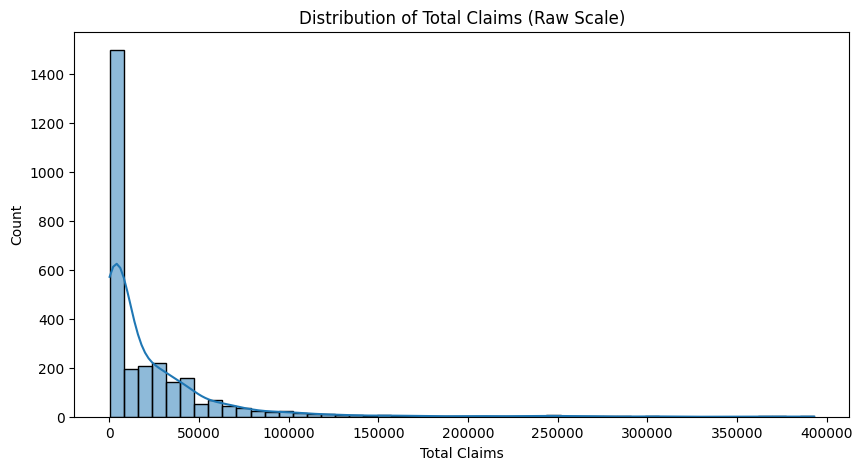

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(df["TotalClaims"][df["TotalClaims"] > 0], bins=50, kde=True)
plt.title("Distribution of Total Claims (Raw Scale)")
plt.xlabel("Total Claims")
plt.ylabel("Count")
plt.show()


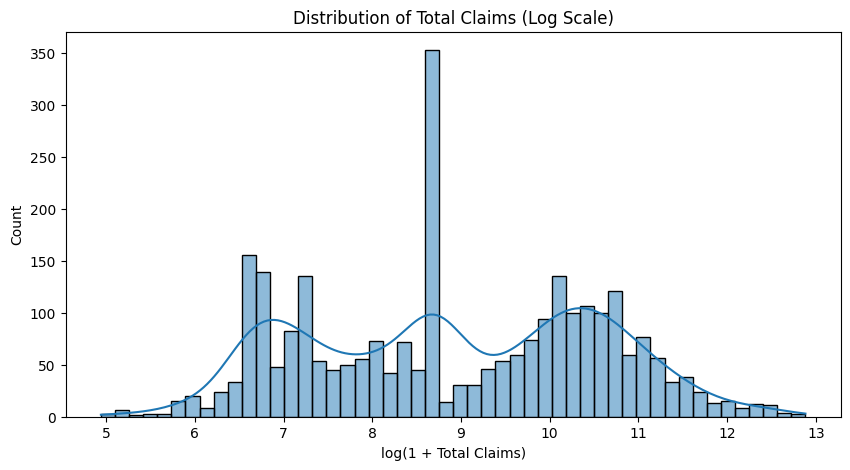

In [12]:
plt.figure(figsize=(10, 5))
sns.histplot(np.log1p(df["TotalClaims"][df["TotalClaims"] > 0]), bins=50, kde=True)
plt.title("Distribution of Total Claims (Log Scale)")
plt.xlabel("log(1 + Total Claims)")
plt.ylabel("Count")
plt.show()


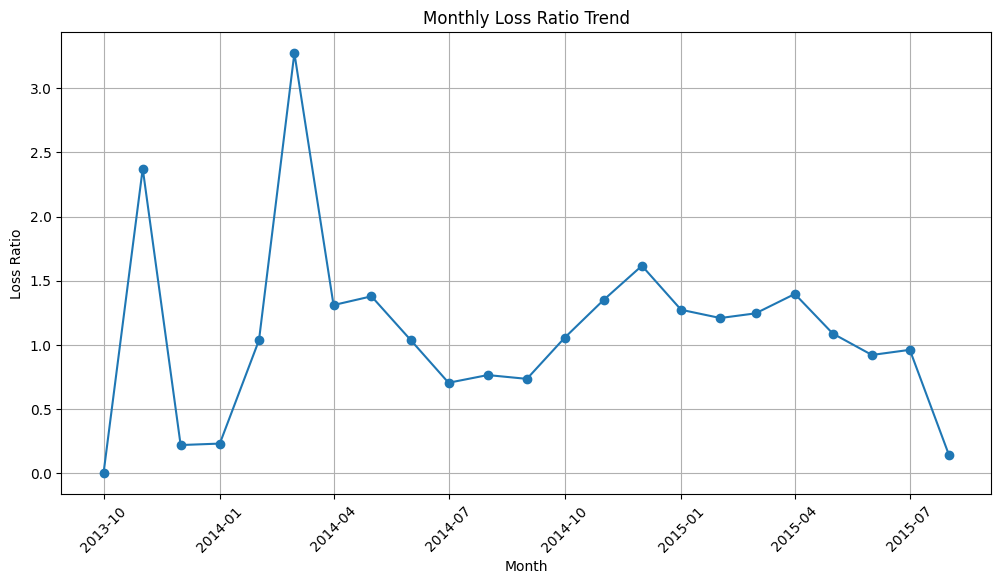

,total_claims,total_premium,loss_ratio
TransactionMonth,,,
2015-04-01,9.076825e+06,6.500269e+06,1.396377
2015-05-01,6.963110e+06,6.400050e+06,1.087977
2015-06-01,6.204182e+06,6.737930e+06,0.920785
2015-07-01,6.751214e+06,7.026171e+06,0.960867
2015-08-01,1.019819e+06,7.281043e+06,0.140065


In [13]:
monthly = df.groupby("TransactionMonth").agg(
    total_claims=("TotalClaims", "sum"),
    total_premium=("TotalPremium", "sum")
)

monthly["loss_ratio"] = monthly["total_claims"] / monthly["total_premium"]

plt.figure(figsize=(12, 6))
plt.plot(monthly.index, monthly["loss_ratio"], marker="o")
plt.title("Monthly Loss Ratio Trend")
plt.xlabel("Month")
plt.ylabel("Loss Ratio")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

monthly.tail()
